## **1. Theoretical Note: Inflation and its Impact on Fixed-Income Amortization**

### **1.1 The Dynamics of the Price Level and Inflation**
Inflation represents the rate of change in the general price level of an economy over a specific period. Let $P_t$ denote the aggregate price index at time $t$. The discrete annualized inflation rate $\pi_t$ is defined as the relative variation in the price index:

$$\pi_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

For continuous financial modeling, we frequently utilize the logarithmic (continuously compounded) rate of inflation:

$$\pi_t = \ln(P_t) - \ln(P_{t-1})$$

### **1.2 The Fisher Equation**
The foundational relationship between nominal interest rates ($R$), real interest rates ($r$), and expected inflation ($\pi^e$) is governed by the Fisher Equation. It posits that the nominal interest rate must compensate the lender for both the time value of money and the expected loss of purchasing power:

$$1 + R = (1 + r)(1 + \pi^e)$$

### **1.3 Impact on Unindexed Debt Structures**
In the context of fixed-rate loans, the nominal cash flows ($C_k$) are deterministic and contractually fixed at inception ($t=0$). However, the *real* value of these cash flows ($c_k$) decays as inflation realizes. For a payment occurring at time $k$, assuming a constant periodic inflation rate $\pi$:

$$c_k = \frac{C_k}{(1 + \pi)^k}$$

Consequently, unexpected positive inflation shocks ($\pi > \pi^e$) trigger a wealth transfer from the lender (creditor) to the borrower (debtor).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%load_ext sql
%sql duckdb:///:memory:

Connecting to 'duckdb:///:memory:'

In [2]:
%%sql
INSTALL httpfs;
LOAD httpfs;

Running query in 'duckdb:///:memory:'

Success


In [4]:
%%sql cpi_data <<
WITH eurostat_raw AS (
    SELECT 
        TIME_PERIOD AS year, 
        CASE REF_AREA 
            WHEN 'IT' THEN 'Italy'
            WHEN 'FR' THEN 'France'
            WHEN 'DE' THEN 'Germany'
            WHEN 'ES' THEN 'Spain'
            ELSE REF_AREA 
        END AS sovereign_state,
        CAST(OBS_VALUE AS FLOAT) AS Valore_CPI
    FROM read_csv_auto('https://data-api.ecb.europa.eu/service/data/ICP/A.IT+FR+DE+ES.N.000000.4.AVR?format=csvdata')
    WHERE OBS_VALUE IS NOT NULL
)
SELECT * FROM eurostat_raw 
ORDER BY year ASC, sovereign_state ASC;

Running query in 'duckdb:///:memory:'

## 2. Historical Trajectories of Inflation Rates
Visualizing the temporal evolution of CPI across primary Eurozone economies to identify aggregate structural shocks.

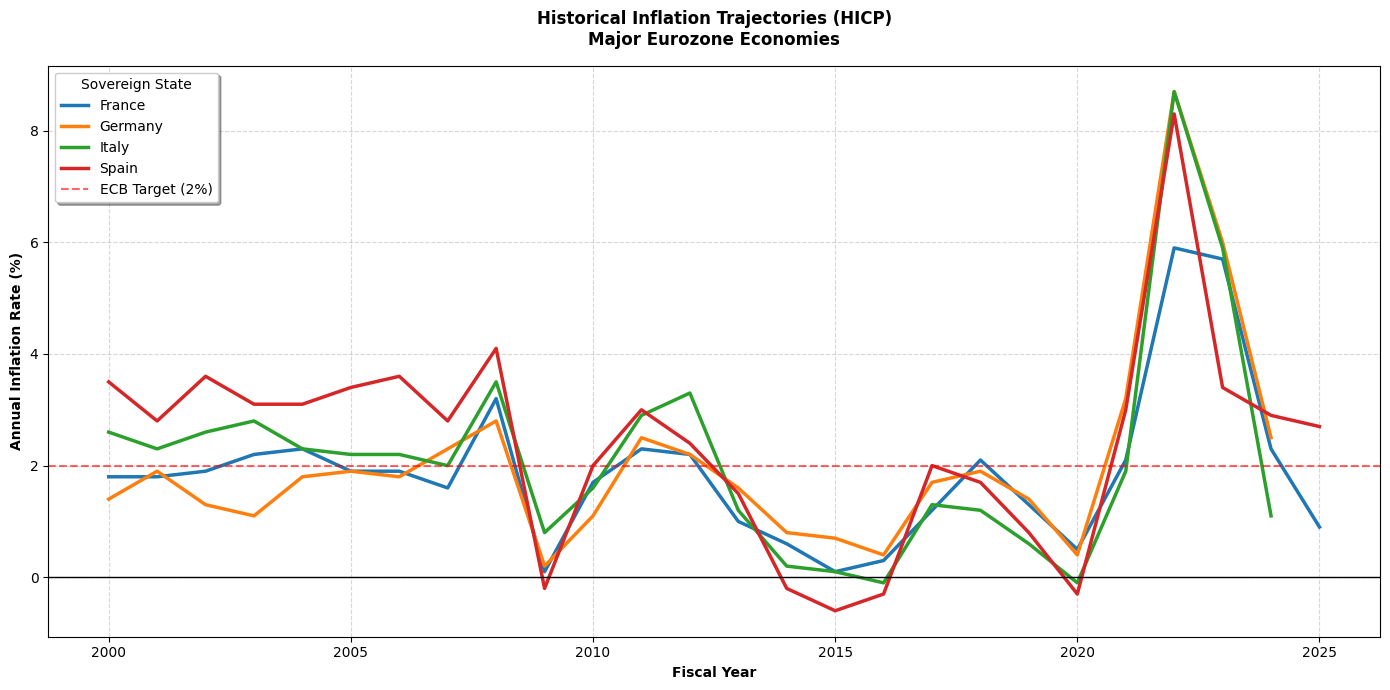

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Copiamo il DataFrame generato da DuckDB
cpi_data = cpi_data.DataFrame()
df_raw = cpi_data.copy()

# 2. Assicuriamoci che l'anno sia numerico per poter applicare il filtro matematico (>= 2000)
df_raw['year'] = pd.to_numeric(df_raw['year'])

# 3. Effettuiamo il pivot usando 'Valore_CPI' come colonna dei valori
df_ts = df_raw.pivot(index='year', columns='sovereign_state', values='Valore_CPI')

# 4. Filtriamo per i decenni recenti
df_ts = df_ts[df_ts.index >= 2000]

# Creazione del grafico
fig, ax = plt.subplots(figsize=(14, 7))

# Tracciamo una linea per ogni nazione
for country in df_ts.columns:
    ax.plot(df_ts.index, df_ts[country], linewidth=2.5, label=country)

# Formattazione Linee di Riferimento
ax.axhline(0, color='black', linewidth=1, linestyle='-') # Deflazione (sotto lo zero)
ax.axhline(2, color='red', linewidth=1.5, linestyle='--', alpha=0.6, label='ECB Target (2%)')

# Estetica e Titoli
ax.set_title('Historical Inflation Trajectories (HICP)\nMajor Eurozone Economies', fontweight='bold', pad=15)
ax.set_xlabel('Fiscal Year', fontweight='bold')
ax.set_ylabel('Annual Inflation Rate (%)', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Sovereign State', loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## 3. Cross-Sectional Comparison
Isolating the most recent data point to conduct a static comparative analysis of the monetary deterioration across the selected states.

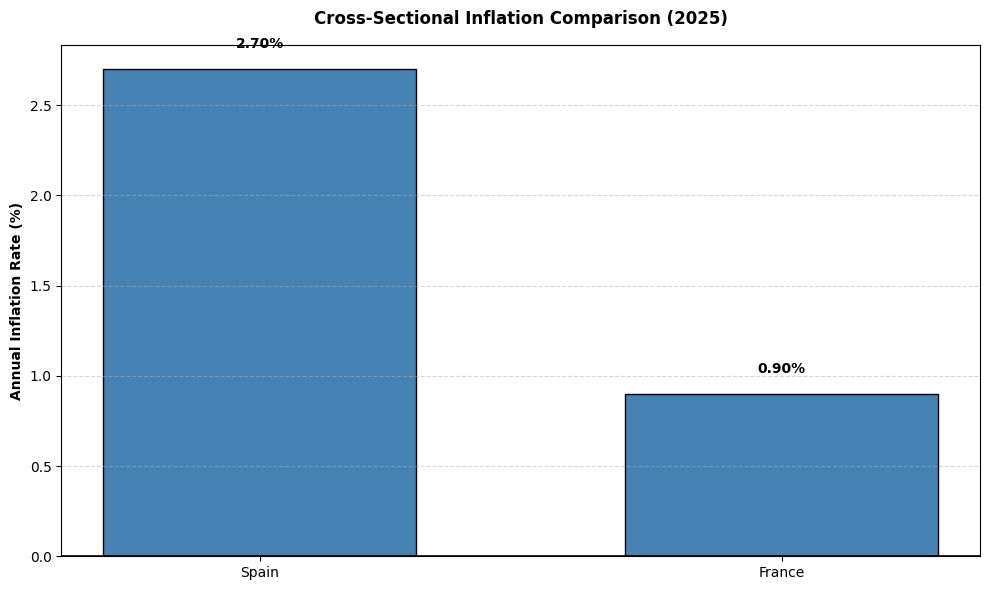

In [7]:
import matplotlib.pyplot as plt

# 1. Troviamo l'anno più recente nel dataset (assicurandoci che sia numerico)
df_raw['year'] = pd.to_numeric(df_raw['year'])
latest_year = df_raw['year'].max()

# 2. Filtriamo e ordiniamo in base al nome corretto della colonna: 'Valore_CPI'
df_latest = df_raw[df_raw['year'] == latest_year].sort_values(by='Valore_CPI', ascending=False)

# Creazione del grafico a barre
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(df_latest['sovereign_state'], df_latest['Valore_CPI'], width=0.6, color='steelblue', edgecolor='black')

# Aggiunta delle etichette dei valori sopra le barre
for bar in bars:
    yval = bar.get_height()
    # Aggiunge uno spazio dinamico (es. +0.1) per far respirare il testo sopra la barra
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

# Formattazione Estetica
ax.set_title(f'Cross-Sectional Inflation Comparison ({latest_year})', fontweight='bold', pad=15)
ax.set_ylabel('Annual Inflation Rate (%)', fontweight='bold')
ax.axhline(0, color='black', linewidth=1.2) # Evidenzia l'asse dello zero (deflazione)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()